In [26]:
import qcodes as qc
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

In [27]:
plt.style.use(['science','no-latex'])

In [28]:
db_path = r"C:\Users\emile\Thesis\Data_processing\Marcus_old_sample\Marcus_old_sample.db"

qc.initialise_or_create_database_at(db_path)

experiment = qc.load_or_create_experiment(experiment_name="resonant transmission ", sample_name="Marcus_old_sample")

In [29]:
#experiment

In [30]:
def load_and_extract(run_id):
    dataset = qc.load_by_run_spec(experiment_name="resonant transmission ", captured_run_id=run_id)
    data = dataset.get_parameter_data()
    countrate = data["countrate"]["countrate"]
    voltage = data["countrate"]["keysight_ch1_source_voltage"]
    wavelength = data["countrate"]["santec_wavelength"]
    return countrate, voltage, wavelength

In [31]:
dataset = qc.load_by_run_spec(experiment_name="resonant transmission ", captured_run_id=70)

In [32]:
dataset

Column_4 #70@C:\Users\emile\Thesis\Data_processing\Marcus_old_sample\Marcus_old_sample.db
-----------------------------------------------------------------------------------------
keysight_ch1_source_voltage - numeric
santec_wavelength - numeric
countrate - numeric

In [33]:
data = dataset.get_parameter_data()
data["countrate"].keys()

dict_keys(['countrate', 'keysight_ch1_source_voltage', 'santec_wavelength'])

In [34]:
countrate, voltage, wavelength = load_and_extract(70)
c = 299792458
frequency = c / (wavelength * 1e-9)

In [35]:
voltage

array([[-0.3  , -0.3  , -0.3  , ..., -0.3  , -0.3  , -0.3  ],
       [-0.301, -0.301, -0.301, ..., -0.301, -0.301, -0.301],
       [-0.302, -0.302, -0.302, ..., -0.302, -0.302, -0.302],
       ...,
       [-0.398, -0.398, -0.398, ..., -0.398, -0.398, -0.398],
       [-0.399, -0.399, -0.399, ..., -0.399, -0.399, -0.399],
       [-0.4  , -0.4  , -0.4  , ..., -0.4  , -0.4  , -0.4  ]])

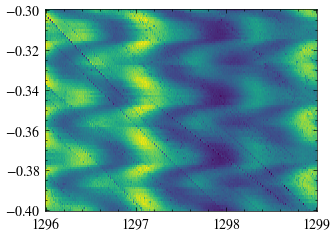

In [36]:
plt.pcolormesh(wavelength, voltage, countrate)

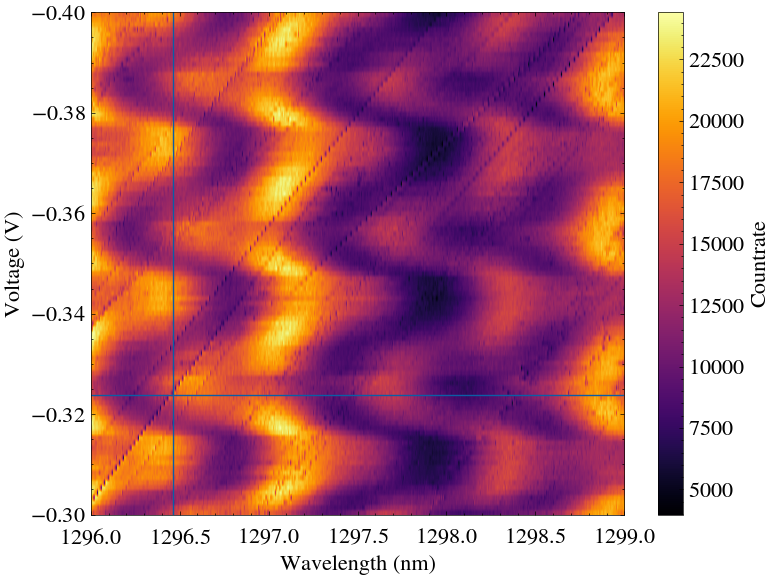

In [37]:
plt.figure(figsize= (8,6))
im = plt.imshow(
    countrate,
    cmap = "inferno",
    aspect='auto',
    origin='lower',
    extent=[wavelength.min(), wavelength.max(),
            voltage.max(), voltage.min()] # Note that extent had flipped the axes, which is shown in the pcolormesh above 
)
plt.xlabel("Wavelength (nm)", fontsize = 16)
plt.ylabel("Voltage (V)", fontsize = 16)
plt.axvline(1296.462)
plt.axhline(-0.3239)
cbar = plt.colorbar(im)
cbar.set_label("Countrate", fontsize=16, rotation = 90)
cbar.ax.tick_params(labelsize=16)
#plt.xlim(1296.3, 1296.8)
#plt.ylim(-0.35, -0.30)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.tick_params(labelsize = 16)
plt.tick_params(axis='x', pad=10)
plt.tight_layout()
#plt.savefig("plots/2d_wavelength_voltage.png", dpi = 300)
plt.show()


In [38]:
countrate_corrected = np.fft.fftshift(np.fft.fft2(countrate))

In [39]:
from matplotlib.colors import LogNorm

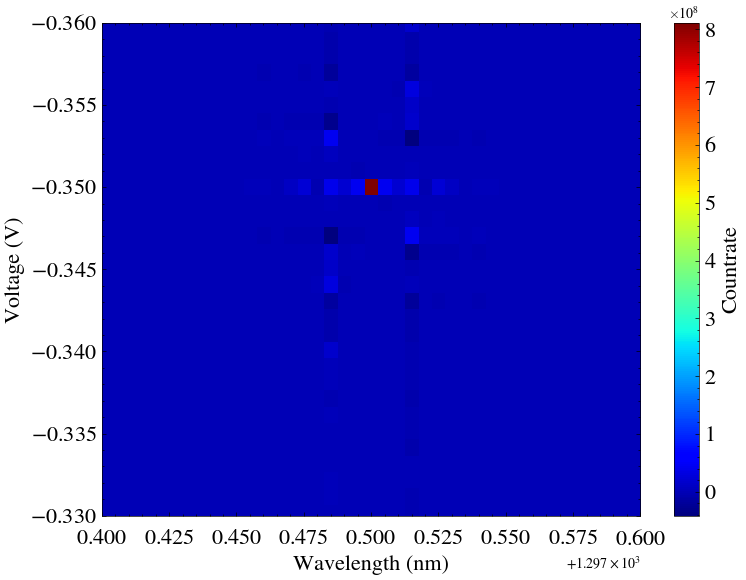

In [40]:
plt.figure(figsize= (8,6))
im = plt.imshow(
    countrate_corrected.real,
    cmap = "jet",
    aspect='auto',
    origin='lower',
    extent=[wavelength.min(), wavelength.max(),
            voltage.max(), voltage.min()]# Note that extent had flipped the axes, which is shown in the pcolormesh above 
)
plt.xlabel("Wavelength (nm)", fontsize = 16)
plt.ylabel("Voltage (V)", fontsize = 16)
plt.axvline(1296.462)
plt.axhline(-0.3239)
cbar = plt.colorbar(im)
cbar.set_label("Countrate", fontsize=16, rotation = 90)
cbar.ax.tick_params(labelsize=16)
plt.xlim(1297.4, 1297.6)
plt.ylim(-0.33, -0.36)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.tick_params(labelsize = 16)
plt.tick_params(axis='x', pad=10)
plt.tight_layout()
#plt.savefig("plots/2d_wavelength_voltage.png", dpi = 300)
plt.show()


In [41]:
voltage_axis = np.unique(voltage)

wavelength_axis = np.unique(wavelength)

print(len(voltage_axis), len(wavelength_axis))

101 601


In [42]:
mask = (wavelength_axis > 1296.3) & (wavelength_axis < 1296.8)
wavelength_crop = wavelength_axis[mask]
countrate_crop = countrate[:, mask]  # rows = voltage, columns = wavelength
# Find the index of the minimum along the wavelength axis for each voltage
dip_indices = np.argmin(countrate_crop, axis=1)

# Map indices to actual wavelength values
dip_wavelengths = wavelength_crop[dip_indices]

In [43]:
coeffs = np.polyfit(voltage_axis, dip_wavelengths, 1)
slope_nm_per_V = coeffs[0]
intercept = coeffs[1]

print("Stark tuning slope:", slope_nm_per_V, "nm/V")

Stark tuning slope: 0.45276645311626573 nm/V


In [44]:
V_fit = np.linspace(voltage_axis.min(), voltage_axis.max(), 200)

lambda_fit = slope_nm_per_V * V_fit + intercept

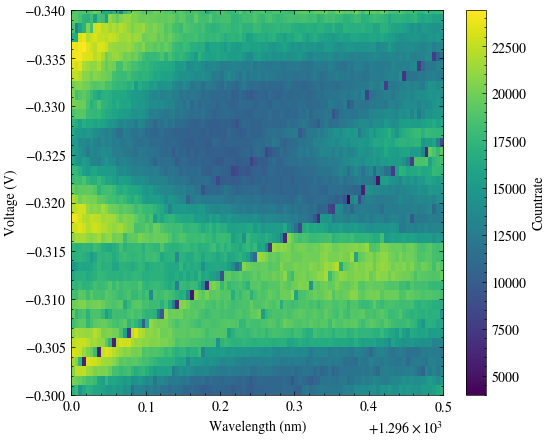

In [45]:
plt.figure(figsize=(6,5))
plt.imshow(
    countrate,
    aspect='auto',
    origin='lower',
    extent=[wavelength_axis.min(), wavelength_axis.max(),
            voltage_axis.max(), voltage_axis.min()]
)
plt.colorbar(label="Countrate")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Voltage (V)")

# Overlay the Stark slope in red
#plt.plot(lambda_fit, V_fit, 'r-', linewidth=2, label='Stark fit')

plt.xlim(1296, 1296.5)  # zoom in near the resonance if you like
#plt.ylim(voltage_axis.min(), voltage_axis.max())
plt.ylim(-0.30, -0.34)
#plt.legend()
plt.show()